# Improving Genetic Algorithms for Product Storage Allocation
##### By: Ashley Bedford, Mayank Gaba, and Nia Foy
We will explore a solution to a real-world bin-packing problem by implementing a Genetic Algorithm (GA). Then, we will work to modify our GA in several ways and explore the results.

### Import Libraries

In [3]:
import enum
import math
import random
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set Global Parameters
- We have set our reproduction rate (15%) will only allow us to create new children if we have a random value above this rate.
- Our crossover rate (53%) will only allow us to conduct one-point crossover on our children half of the time.
- Our mutation rate (1.3%) will do a one-bit mutation on our children rarely.

In [4]:
REPRO_RATE = 0.15 # Reproduction Rate
CROSS_RATE = 0.53 # Crossover rate 
MUTATE_RATE = 0.013 # Mutation Rate

### Define the Zone Class
Here we define our Small, Medium, and Large Zones. Each size will have dimension attributes that allow us to calculate the volume available to fill with boxes.

In [5]:
class Zone():
    def __init__(self):
        self.length =     4
        self.totalWidth = 5
        self.height  =  5

    def change(self, size):
        if size == 'Medium':
            self.length = 8
           
        elif size == 'Large':
            self.length = 16
    def getVolume(self):
        return(self.length * self.totalWidth * self.height)   
        

### Define the Box Class
This allows us to create square boxes for each zone. Square boxes allow us to account for the orientation and dimensions of our boxes when calculating the the total volume used accurately.

In [6]:
class Box():
    def __init__(self):
        self.length         = 1
        self.width          = 1
        self.height         = 1
        self.size = 'Small'
    def change(self, size):
        if size == 'Medium':
            self.length     = 2
            self.width      = 2
            self.height     = 2
            self.size = 'Medium'
        elif size == 'Large':
            self.length     = 4
            self.width      = 4
            self.height     = 4
            self.size = 'Large'
    def getVolume(self):
        return(self.length * self.width * self.height )
    def __repr__(self):
        return('Box')          
    

### Define the Create Zones Method
This method will create each of our zones for us in a dictionary format. The zones will be our dictionary keys.

In [7]:
# create zones
def create_zones(small, medium, large):
    zones  = {'Small': [] , 'Medium': [], 'Large': []}
    
    
    for i in range(small): #create specified zone objects
        small_zone = Zone()
        temp = zones['Small']
        temp.append(small_zone)
        zones['Small'] = temp
        
    for i in range(medium): #create specified zone objects
        med_zone = Zone()
        med_zone.change('Medium')
        temp = zones['Medium']
        temp.append(med_zone)
        zones['Medium'] = temp
    for i in range(large): #create specified zone objects
        large_zone = Zone()
        large_zone.change('Large')
        temp = zones['Large']
        temp.append(large_zone)
        zones['Large'] = temp
        
    return zones    

### Define the Create Boxes Method
This method will create each of our boxes for us in a list of solutions format. The boxes will be our dictionary values.

In [8]:
def create_boxes(small, medium, large):
    boxes  = {'Small': [] , 'Medium': [], 'Large': []}
    for i in range(small): #create specified box object
        small_box = Box()
        temp = boxes['Small']
        temp.append(small_box)
        boxes['Small'] = temp
        
    for i in range(medium): #create specified box object
        med_box = Box()
        med_box.change('Medium')
        temp = boxes['Medium']
        temp.append(med_box)
        boxes['Medium'] = temp
        
    for i in range(large): #create specified box object
        large_box = Box()
        large_box.change('Large')

        temp = boxes['Large']
        temp.append(large_box)
        boxes['Large'] = temp
    return boxes


### Define the Find Used Volume Method
This is a method to find the total used volume in a zone.

In [9]:
def find_usedVolume(box_list, chromo_list):
    idx = 0
    volume =0
    for i in box_list:
        v = i.getVolume()
        if chromo_list[idx] ==1:
            volume += v
        idx +=1
    return volume

### Define the Find Total Volume Method
This is a method to find the total volume available in a zone.

In [10]:
def find_total_volume(Zones):
    volume =0
    for z in Zones:
        v = z.getVolume()
        volume += v
    return volume

### Define the Fitness Function
We are defining our fitness function by looking at the percent of space used out of our total space capacity per zone.
The higher the percent of space used.

In [11]:
def fitness_function(boxes, zones, chromosome):

    
    total_used_Volume = find_usedVolume(boxes, chromosome)
    total_volume      =  find_total_volume(zones)
    
    if total_used_Volume > total_volume:
        return 0
    else:
        #print('Total Used Space        : ',total_used_Volume)
        #print('Total Available Space   : ', total_volume)
        return (total_used_Volume / total_volume)
    
    
    

### Comparing Genetic Algorithm Inmprovements (Standard vs Strong)

##### Initialize our Population (Standard Method)
We are initializing our population with random solutions.

In [12]:
def init_population(box_dict, count):
    population = {}
    for size in box_dict:
        box_list = box_dict[size]
        chromosome = []
        size_grouping = []
        x = 0
        while x != count:
            for box in box_list:
                chromosome.append(np.random.randint(0,2))
            size_grouping.append(chromosome.copy())
            chromosome.clear()
            x = x + 1
        population[size] = size_grouping
        #print(len(size_grouping))
    a = len(population['Small'])
    b = len(population['Medium'])
    c = len(population['Large'])
    #print(a,b,c)
    return population
    

##### Initialize our Population (Strong Method)
We modify our standard solution to only include ones that have a fitness value of 85% or over.

In [13]:
def init_strong_population(box_dict, count):
    population = {}
    for size in box_dict:
        box_list = box_dict[size]
        chromosome = []
        size_grouping = []
        x = 0
        while x != count:
            for box in box_list:
                if random.random() <0.85:
                    chromosome.append(1)
                else:
                    chromosome.append(0)
            size_grouping.append(chromosome.copy())
            chromosome.clear()
            x = x + 1
        population[size] = size_grouping
        #print(len(size_grouping))
    a = len(population['Small'])
    b = len(population['Medium'])
    c = len(population['Large'])
    #print(a,b,c)
    return population

##### Select our Parents (Standard Method)
Here we will randomly select our parents and use them to create children solutions.

In [14]:
def parent_selection(box_dict, zone_dict, population):
    parents = {}
    for size in population:
        boxes = box_dict[size]
        zones = zone_dict[size]
        new_parents =[]
        all_parents =population[size]
        for i in range(4):
            k = random.randint(0, len(all_parents)-1)
            new_parents.append(all_parents[k])
        parents[size] = new_parents
    return parents

##### Select our Parents (Strong Method)
We have modified our standard parent selection method by only choosing solutions with a high fitness score.

In [15]:
def strong_parent_selection(box_dict, zone_dict, population):
    parents = {}
    for size in population:
        boxes = box_dict[size]
        zones = zone_dict[size]
        scores ={}
        temp =[]
        idx =0
        for chromosome in population[size]:
            answer = fitness_function(boxes, zones, chromosome)
            scores[answer] = chromosome
            temp.append(answer)
        temp.sort(reverse = True)
        new_parents =[]
        for i in range(4):
            high = temp[i]
            new_parents.append(scores[high])
        parents[size] = new_parents
    return parents

##### Create our Next Generation
Here we create our children, add them to our population and remove our parents.

In [39]:
def next_generation(box_dict, population , parents):
    next_gen = {}


    for size in population:
        next_gen[size] =[]
        cur_parents =parents[size]
        while len(next_gen[size]) < (len(population[size]) - len(parents[size])):
            children =[]
            if random.random() < REPRO_RATE:
                children = population[size]
            else:
                if random.random() < CROSS_RATE:
                    cross_children = crossover(parents[size])  # We will perform one-point crossover on our children
                    for child in cross_children:
                        children.append(child)
                if random.random() < MUTATE_RATE:
                    children = bit_flip_mutation(children)  # We will perform one-bit mutation on our children
            cur = next_gen[size]
            for child in children:
                if len(cur) == len(population[size]):
                    continue
                cur.append(child)
        index =random.randint(0, len(population[size]) -1)
        while len(next_gen[size]) < len(population[size]):
            cur = next_gen[size]
            prev = population[size][index]
            cur.append(prev)
            index  = random.randint(0, len(population[size]) -1)
            next_gen[size] = cur

    return next_gen

##### One-Point Crossover Function 
One random point will be used to specify the location of the split in our parents' chromosomes and swap each halve into child solutions. 

In [40]:
def crossover(parents):
    #list [0,1,0,1,0,1],[0,1,0,10,1,01]
    chromo_length = len(parents[0])
    a,b =0,1
    children =[]
    while b < (len(parents)):
        first = parents[a]
        second = parents[b]
        child=first.copy()  
        child2=second.copy()
        k = random.randint(0, chromo_length)
        for i in range(k, chromo_length):
            child[i], child2[i] = child2[i],child[i]
        children.append(child)
        children.append(child2)
        a +=2
        b +=2
       
    return children

    

##### Bit-Flip Mutation
We will mutate the children by picking random location(s) and flipping it's chromosome bits.

In [41]:
def bit_flip_mutation(children):
    new_children =[]
    for chromosome in children:
        for i in range(len(chromosome)):
            if random.random() < MUTATE_RATE:
                if chromosome[i] ==0:
                    chromosome[i] =1
                else:
                    chromosome[i] = 0

    return children

##### Record the Best Fitness in a Generation
In order to plot the best fitness value in each generation, we must store them in a dictionary.

In [42]:
def get_best_fitness(box_dict, zone_dict, population):
    fitness_values ={'Small':0, 'Medium':0, 'Large': 0}
    for size in population:
        boxes = box_dict[size]
        zones = zone_dict[size]
        for chromosome in population[size]:
            fitness_value = fitness_function(boxes, zones, chromosome)
            max_fitness = max(fitness_values[size] , fitness_value)
            fitness_values[size] = max_fitness
    return fitness_values
    
    

### Implement Genetic Algorithm

##### Parent Selection with One-Point Crossover (Standard)
Here we implement a standard parent selection method in our GA iterations.

In [43]:
def cycler(box_dict, zone_dict, population):
    num_cycles = 5000
    index =0
    final ={}
    while index < num_cycles:
        parents =parent_selection(box_dict, zone_dict, population)
        population = next_generation(box_dict, population , parents)
        fitness_values =get_best_fitness(box_dict, zone_dict, population)
        final[index] = fitness_values
        index +=1   
    return final

##### Parent Selection with One-Point Crossover (Strong)
This modified version of our standard GA allows us to implement a our IMPROVEMENT A solution.

In [44]:
def strong_cycler(box_dict, zone_dict, population):
    num_cycles = 5000
    index =0
    final ={}
    while index < num_cycles:
        parents =strong_parent_selection(box_dict, zone_dict, population)
        population = next_generation(box_dict, population , parents)
        fitness_values =get_best_fitness(box_dict, zone_dict, population)
        final[index] = fitness_values
        index +=1   
    return final

##### Convert GA to DataFrame for Plotting Results

In [45]:
def convert_to_df(result):
    new_dict = {'Small': [] , 'Medium': [], 'Large': []}
    for key in result:
        dict1 = result[key]
        for size in dict1:
            cur = new_dict[size]
            cur.append(dict1[size])
            new_dict[size] = cur
    df =pd.DataFrame.from_dict(new_dict)
    return df

### GA Improvement Results

##### Standard GA
We run a GA that is our baseline for comparison against the different improvements we would like to make.
The Standard GA includes:
- Population Initialization: an initial population that is set through random bits
- Parent Selection: a set of parents are selected randomly
- Children: children are created through a one-point crossover method from the parents and then go through a one-bit mutation
- Survivor Selection: parents are replaced by their children and the GA cycle continues

Our result looks flat and randomized. We could not break through a 70% fitness value overall.

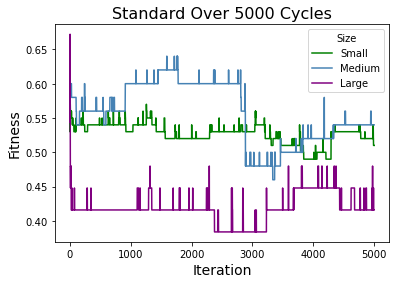

In [46]:
def standard():
    
    # Create boxes per zone
    num_small = 100  # Max boxes per Small zone = 100
    num_med   = 50  # Max boxes per Medium Zone = 50
    num_large = 30  # Max boxes per Large Zone = 30
    
    # Assign number of zones per size
    small_zones = 1
    med_zones   = 2
    large_zones = 5
    
    # Run the Genetic Algorithm
    NUM_POP_SOLUTIONS = 10
    box_dict = create_boxes(num_small, num_med, num_large)
    zone_dict = create_zones(small_zones ,med_zones, large_zones)
    population = init_population(box_dict, NUM_POP_SOLUTIONS)
    result = cycler(box_dict, zone_dict, population)
    
    # Plot our Results
    df = convert_to_df(result)
    plt.plot(df['Small'], label='Small', color='green')
    plt.plot(df['Medium'], label='Medium', color='steelblue')
    plt.plot(df['Large'], label='Large', color='purple')
    plt.legend(title='Size')
    plt.ylabel('Fitness', fontsize=14)
    plt.xlabel('Iteration', fontsize=14)
    plt.title('Standard Over 5000 Cycles', fontsize=16)
    plt.show()
standard()

##### IMPROVEMENT A: Strong Population Initialization

Suprisingly, our result decreases over time (~90% to 70%). This produced the opposite result we were looking for.

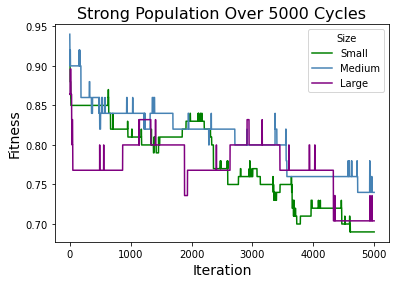

In [47]:
def strong_population():

    num_small = 100  
    num_med   = 50  
    num_large = 30 
    
    small_zones = 1
    med_zones   = 2
    large_zones = 5
    
    NUM_POP_SOLUTIONS = 10
    box_dict = create_boxes(num_small, num_med, num_large)
    zone_dict = create_zones(small_zones ,med_zones, large_zones)
    
    # We replaced our standard population initialization with our strong one
    population = init_strong_population(box_dict, NUM_POP_SOLUTIONS)  
    
    result = cycler(box_dict, zone_dict, population)
    
    df = convert_to_df(result)
    plt.plot(df['Small'], label='Small', color='green')
    plt.plot(df['Medium'], label='Medium', color='steelblue')
    plt.plot(df['Large'], label='Large', color='purple')
    plt.legend(title='Size')
    plt.ylabel('Fitness', fontsize=14)
    plt.xlabel('Iteration', fontsize=14)
    plt.title('Strong Population Over 5000 Cycles', fontsize=16)
    #display plot
    plt.show()
strong_population()

##### IMPROVEMENT B: Strong Parent Selection with One-Point Crossover

We have very strong results with almost all of our zone sizes reaching 100% fitness values. This is a favorable result.

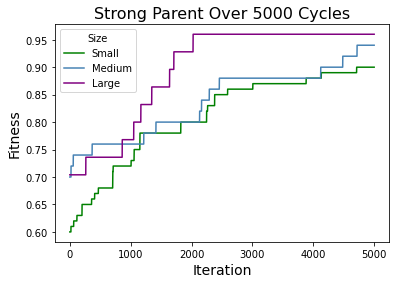

In [48]:
def strong_parent():

    num_small = 100 
    num_med   = 50  
    num_large = 30  
    
    small_zones = 1
    med_zones   = 2
    large_zones = 5
    
    NUM_POP_SOLUTIONS = 10
    box_dict = create_boxes(num_small, num_med, num_large)
    zone_dict = create_zones(small_zones ,med_zones, large_zones)
    population = init_population(box_dict, NUM_POP_SOLUTIONS)
    
    # We replaced our standard parent selection method with our strong one
    # while also using a one-point crossover method during children creation
    result = strong_cycler(box_dict, zone_dict, population)
    
    df = convert_to_df(result)
    plt.plot(df['Small'], label='Small', color='green')
    plt.plot(df['Medium'], label='Medium', color='steelblue')
    plt.plot(df['Large'], label='Large', color='purple')
    plt.legend(title='Size')
    plt.ylabel('Fitness', fontsize=14)
    plt.xlabel('Iteration', fontsize=14)
    plt.title('Strong Parent Over 5000 Cycles', fontsize=16)
    #display plot
    plt.show()
strong_parent()

##### IMPROVEMENT A & B: Strong Population Initialization and Strong Parent Selection

Using both a strong population initialization and strong parent selection method with one-point crossover, we see that the fitness values over time increase by a much larger percent change when compared to IMPROVEMENT B alone, making this a favorable result as well.

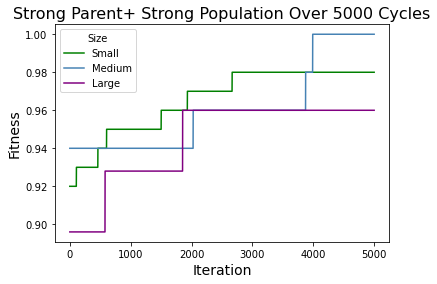

In [50]:
def strong_parent_population():

    num_small = 100 
    num_med   = 50  
    num_large = 30  
    
    small_zones = 1
    med_zones   = 2
    large_zones = 5
    
    NUM_POP_SOLUTIONS = 10
    box_dict = create_boxes(num_small, num_med, num_large)
    zone_dict = create_zones(small_zones ,med_zones, large_zones)
    population = init_strong_population(box_dict, NUM_POP_SOLUTIONS)
    result = strong_cycler(box_dict, zone_dict, population)
    
    df = convert_to_df(result)
    plt.plot(df['Small'], label='Small', color='green')
    plt.plot(df['Medium'], label='Medium', color='steelblue')
    plt.plot(df['Large'], label='Large', color='purple')
    plt.legend(title='Size')
    plt.ylabel('Fitness', fontsize=14)
    plt.xlabel('Iteration', fontsize=14)
    plt.title('Strong Parent+ Strong Population Over 5000 Cycles', fontsize=16)
    #display plot
    plt.show()
strong_parent_population()